In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 1.4.2
numpy: 1.26.4


In [3]:
url = "../data/raw/rest_1_covers_new.csv"
df = pd.read_csv(url)
df.head()

,date,inside_sales,outside_sales,inside_covers,outside_covers,reserved_covers,walkin_covers,waitlist_covers,no_show_covers,no_show_parties
0,2017-01-02,13159.84,0.0,174.0,0,106.0,26.0,42.0,17.0,6.0
1,2017-01-03,12442.11,0.0,181.0,0,119.0,31.0,31.0,14.0,4.0
2,2017-01-04,12927.64,0.0,174.0,0,131.0,17.0,26.0,5.0,2.0
3,2017-01-05,14457.79,0.0,191.0,0,138.0,25.0,28.0,4.0,2.0
4,2017-01-06,15331.97,0.0,200.0,0,130.0,16.0,54.0,6.0,3.0


In [6]:
# df.to_csv("../data/raw/rest_1_covers_new.csv", index=False)
# print("Файл сохранён в data/raw/")

Файл сохранён в data/raw/


In [4]:
print("Размер датасета:")
print(df.shape)

print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

Размер датасета:
(910, 10)

Названия столбцов:
['date', 'inside_sales', 'outside_sales', 'inside_covers', 'outside_covers', 'reserved_covers', 'walkin_covers', 'waitlist_covers', 'no_show_covers', 'no_show_parties']

Типы данных:
date                object
inside_sales       float64
outside_sales      float64
inside_covers      float64
outside_covers       int64
reserved_covers    float64
walkin_covers      float64
waitlist_covers    float64
no_show_covers     float64
no_show_parties    float64
dtype: object


In [5]:
df["date"] = pd.to_datetime(df["date"])
print(df.dtypes)

date               datetime64[ns]
inside_sales              float64
outside_sales             float64
inside_covers             float64
outside_covers              int64
reserved_covers           float64
walkin_covers             float64
waitlist_covers           float64
no_show_covers            float64
no_show_parties           float64
dtype: object


In [6]:
print("Минимальная дата:", df["date"].min())
print("Максимальная дата:", df["date"].max())
print("Количество дней:", df["date"].nunique())

Минимальная дата: 2017-01-02 00:00:00
Максимальная дата: 2019-06-30 00:00:00
Количество дней: 910


In [7]:
missing = df.isna().sum()
print(missing)

date                0
inside_sales        0
outside_sales       0
inside_covers      13
outside_covers      0
reserved_covers    13
walkin_covers      13
waitlist_covers    13
no_show_covers     13
no_show_parties    13
dtype: int64


In [8]:
missing[missing > 0]

inside_covers      13
reserved_covers    13
walkin_covers      13
waitlist_covers    13
no_show_covers     13
no_show_parties    13
dtype: int64

In [9]:
print("Количество дубликатов дат:", df["date"].duplicated().sum())

Количество дубликатов дат: 0


In [10]:
print("Даты отсортированы:", df["date"].is_monotonic_increasing)

Даты отсортированы: True


In [11]:
df = df.sort_values("date").reset_index(drop=True)

Есть данные за 910 дней, больше чем за 2 года. Дубликатов дат нет. Присутствуют пропуски, 13 пропусков сразу в 6 столбцах, нужно исследовать.

In [12]:
missing_covers = df[df["inside_covers"].isna()]
missing_covers

,date,inside_sales,outside_sales,inside_covers,outside_covers,reserved_covers,walkin_covers,waitlist_covers,no_show_covers,no_show_parties
34,2017-02-05,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
71,2017-03-14,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
325,2017-11-23,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
356,2017-12-24,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
357,2017-12-25,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
364,2018-01-01,381.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
398,2018-02-04,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
639,2018-10-03,-1000.0,26000.01,NaN,1,NaN,NaN,NaN,NaN,NaN
689,2018-11-22,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN
721,2018-12-24,0.0,0.00,NaN,0,NaN,NaN,NaN,NaN,NaN


In [13]:
full_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(df["date"])

print("Всего календарных дней:", len(full_dates))
print("Дат в датасете:", df["date"].nunique())
print("Отсутствует дат:", len(missing_dates))

print("\nОтсутствующие даты:")
print(missing_dates)

Всего календарных дней: 910
Дат в датасете: 910
Отсутствует дат: 0

Отсутствующие даты:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


Временной ряд календарно непрерывный. Каждая дата от 02.01.2017 до 30.06.2019 присутствует в таблице.
11 дней, где нулевые продажи, вероятнее всего ресторан не работал. Для дат 01.01.2018 и 03.10.2018 отдельно проанализируем ситуацию.

In [14]:
missing_covers = df[df["inside_covers"].isna()].copy()
missing_covers["day_of_week"] = missing_covers["date"].dt.day_name()
missing_covers[[
    "date",
    "day_of_week",
    "inside_sales",
    "outside_sales",
    "outside_covers",
    "inside_covers"
]]

,date,day_of_week,inside_sales,outside_sales,outside_covers,inside_covers
34,2017-02-05,Sunday,0.0,0.00,0,NaN
71,2017-03-14,Tuesday,0.0,0.00,0,NaN
325,2017-11-23,Thursday,0.0,0.00,0,NaN
356,2017-12-24,Sunday,0.0,0.00,0,NaN
357,2017-12-25,Monday,0.0,0.00,0,NaN
364,2018-01-01,Monday,381.0,0.00,0,NaN
398,2018-02-04,Sunday,0.0,0.00,0,NaN
639,2018-10-03,Wednesday,-1000.0,26000.01,1,NaN
689,2018-11-22,Thursday,0.0,0.00,0,NaN
721,2018-12-24,Monday,0.0,0.00,0,NaN


Даты, кроме 01.01.2018 и 03.10.2018, говорят о том что в эти дни ресторан был закрыт, така как отсутствуют все показатели посещаемости, а продажи равны 0. Поэтому inside_covers = 0.

In [15]:
missing_covers["day_of_week"].value_counts()

Sunday       4
Tuesday      3
Monday       3
Thursday     2
Wednesday    1
Name: day_of_week, dtype: int64

Для 2018-01-01 и 2018-10-03 посмотрим информацию по соседним дням:

In [16]:
df[
    df["date"].isin([
        "2017-12-31",
        "2018-01-01",
        "2018-01-02",
        "2018-10-02",
        "2018-10-03",
        "2018-10-04",
        "2018-10-05"
    ])
][[
    "date",
    "inside_sales",
    "outside_sales",
    "inside_covers",
    "outside_covers"
]]

,date,inside_sales,outside_sales,inside_covers,outside_covers
363,2017-12-31,16199.59,0.00,204.0,0
364,2018-01-01,381.00,0.00,NaN,0
365,2018-01-02,11591.75,0.00,163.0,2
638,2018-10-02,14062.59,2153.75,181.0,36
639,2018-10-03,-1000.00,26000.01,NaN,1
640,2018-10-04,16258.59,0.00,40.0,0
641,2018-10-05,14232.60,4800.00,170.0,77


#### Для 01.01.2018:

2017-12-31 → 204 гостя

2018-01-01 → NaN гостей, $381 продаж

2018-01-02 → 163 гостя

Есть $381 продаж, но нет гостей

#### Для 03.10.2018:

2018-10-02 → 181 гость

2018-10-03 → NaN гостей

2018-10-04 → 40 гостей

2018-10-05 → 170 гостей

Аномальные продажи и нет гостей

Эти две строки впоследствии не будем использовать как целевые значения при обучении. Остальные 11 заполняем 0.

In [17]:
closed_like_days = df[
    (df["inside_sales"] == 0) &
    (df["outside_sales"] == 0) &
    (df["outside_covers"] == 0) &
    (df["inside_covers"].isna())
]

print("Количество дней:", len(closed_like_days))

Количество дней: 11


In [18]:
df["is_closed"] = (
    (df["inside_sales"] == 0) &
    (df["outside_sales"] == 0) &
    (df["outside_covers"] == 0) &
    (df["inside_covers"].isna())
)

In [19]:
print(df["is_closed"].value_counts())

False    899
True      11
Name: is_closed, dtype: int64


In [20]:
df.loc[df["is_closed"], "inside_covers"] = 0

In [21]:
cover_columns = [
    "reserved_covers",
    "walkin_covers",
    "waitlist_covers",
    "no_show_covers",
    "no_show_parties"
]

df.loc[df["is_closed"], cover_columns] = 0

In [22]:
closed_like_days = df[
    (df["inside_sales"] == 0) &
    (df["outside_sales"] == 0) &
    (df["outside_covers"] == 0) &
    (df["inside_covers"].isna())
]

print("Количество дней:", len(closed_like_days))

Количество дней: 0


#### Вывод: 
Календарных разрывов в данных не обнаружено. Было обнаружено 13 наблюдений с пропусками показателей посещаемости. Для 11 дат одновременно отсутствовали продажи и показатели посещаемости, поэтому такие дни были интерпретированы как дни закрытия ресторана, значит количество гостей равны нулю. Два оставшихся наблюдения имели нетипичные значения продаж и не позволяли достоверно восстановить целевую переменную, поэтому они были сохранены как пропущенные значения и исключены из расчёта целевой переменной при обучении.

In [23]:
# Создаём признак
df["is_closed"] = False
df.loc[closed_like_days.index, "is_closed"] = True

In [24]:
cover_columns = [
    "inside_covers",
    "reserved_covers",
    "walkin_covers",
    "waitlist_covers",
    "no_show_covers",
    "no_show_parties"
]

df.loc[df["is_closed"], cover_columns] = 0

In [25]:
print("Пропуски после обработки:")
print(df.isna().sum()[df.isna().sum() > 0])

Пропуски после обработки:
inside_covers      2
reserved_covers    2
walkin_covers      2
waitlist_covers    2
no_show_covers     2
no_show_parties    2
dtype: int64


Наш источник содержит один ресторан, поэтому добавим ему ID.

In [26]:
df["restaurant_id"] = 1
target = "inside_covers" # целевая переменная

In [27]:
df.to_csv(
    "../data/processed/restaurant_cleaned.csv",
    index=False
)

print("Обработанный датасет сохранён.")

Обработанный датасет сохранён.


### Целевая переменная во времени

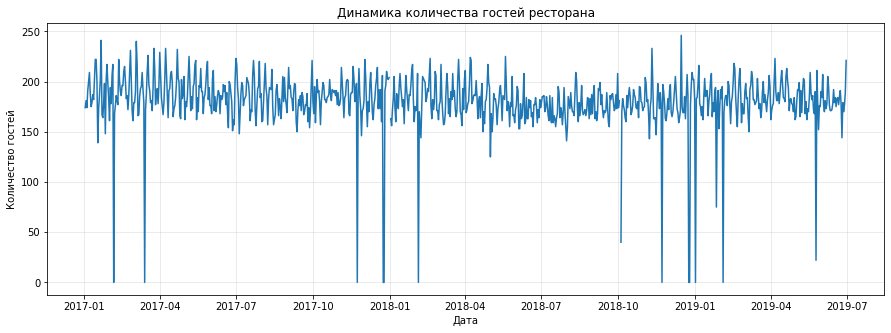

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["date"],
    df["inside_covers"]
)

plt.xlabel("Дата")
plt.ylabel("Количество гостей")
plt.title("Динамика количества гостей ресторана")

plt.grid(True, alpha=0.3)
plt.show()

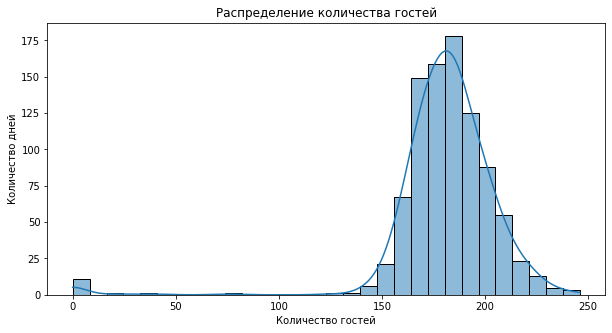

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["inside_covers"].dropna(),
    bins=30,
    kde=True
)

plt.xlabel("Количество гостей")
plt.ylabel("Количество дней")
plt.title("Распределение количества гостей")

plt.show()

In [30]:
df["inside_covers"].describe()

count    908.000000
mean     180.800661
std       27.302481
min        0.000000
25%      171.000000
50%      182.000000
75%      193.250000
max      246.000000
Name: inside_covers, dtype: float64

Основная масса наблюдений находится примерно в диапазоне 160–210 гостей в день. Есть отдельные резкие падения до нуля — это наши ранее обнаруженные закрытые дни. Выраженного монотонного роста или падения за весь период не видно. Поэтому для модели важнее будет учитывать календарную и недельную сезонность. Среднее 180.8 и медиана 182 очень близки, что говорит о том, что основная часть распределения не имеет сильного смещения. Но нулевые дни и отдельные экстремальные наблюдения создают дополнительный хвост.

### Недельная сезонность

Создадим дни недели.

0 — понедельник

1 — вторник

2 — среда

3 — четверг

4 — пятница

5 — суббота

6 — воскресенье

In [31]:
df["day_of_week"] = df["date"].dt.dayofweek
days = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье"
}

df["day_name"] = df["day_of_week"].map(days)

In [32]:
#среднее количество гостей по дням недели
weekly_pattern = (
    df.groupby(["day_of_week", "day_name"])["inside_covers"]
    .mean()
    .reset_index()
)

weekly_pattern

,day_of_week,day_name,inside_covers
0,0,Понедельник,173.736434
1,1,Вторник,167.484615
2,2,Среда,173.961240
3,3,Четверг,173.192308
4,4,Пятница,188.261538
5,5,Суббота,201.269231
6,6,Воскресенье,187.592308


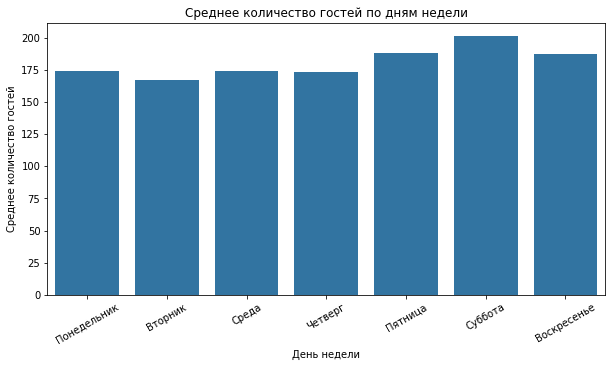

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekly_pattern,
    x="day_name",
    y="inside_covers"
)

plt.xlabel("День недели")
plt.ylabel("Среднее количество гостей")
plt.title("Среднее количество гостей по дням недели")

plt.xticks(rotation=30)
plt.show()

Суббота имеет самое высокое среднее количество гостей — около 201, тогда как вторник (самый мин. количесвтво) — около 167.
Разница между ними составляет примерно: 201.27 - 167.48 ≈ 33.8 гостя. Существенно, следовательно день недели обязательно нужно использовать как признак.

### Месячная сезонность

In [34]:
df["month"] = df["date"].dt.month
monthly_pattern = (
    df.groupby("month")["inside_covers"]
    .mean()
)

monthly_pattern

month
1     181.758242
2     180.238095
3     184.580645
4     188.211111
5     181.182796
6     178.666667
7     180.129032
8     179.193548
9     179.866667
10    179.508197
11    176.566667
12    174.806452
Name: inside_covers, dtype: float64

Месячный эффект есть, но он намного слабее недельного.

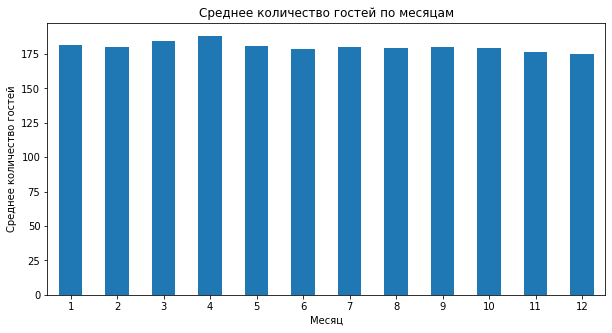

In [35]:
plt.figure(figsize=(10, 5))

monthly_pattern.plot(
    kind="bar"
)

plt.xlabel("Месяц")
plt.ylabel("Среднее количество гостей")
plt.title("Среднее количество гостей по месяцам")

plt.xticks(rotation=0)
plt.show()

Изучим выбросы.

In [36]:
q1 = df["inside_covers"].quantile(0.25)
q3 = df["inside_covers"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Нижняя граница:", lower_bound)
print("Верхняя граница:", upper_bound)

Q1: 171.0
Q3: 193.25
IQR: 22.25
Нижняя граница: 137.625
Верхняя граница: 226.625


In [37]:
outliers = df[
    (df["inside_covers"] < lower_bound) |
    (df["inside_covers"] > upper_bound)
]

print("Количество выбросов:", len(outliers))

outliers[[
    "date",
    "inside_covers",
    "inside_sales",
    "outside_sales"
]].sort_values("inside_covers")

Количество выбросов: 24


,date,inside_covers,inside_sales,outside_sales
357,2017-12-25,0.0,0.00,0.0
34,2017-02-05,0.0,0.00,0.0
729,2019-01-01,0.0,0.00,0.0
722,2018-12-25,0.0,0.00,0.0
71,2017-03-14,0.0,0.00,0.0
721,2018-12-24,0.0,0.00,0.0
689,2018-11-22,0.0,0.00,0.0
398,2018-02-04,0.0,0.00,0.0
762,2019-02-03,0.0,0.00,0.0
325,2017-11-23,0.0,0.00,0.0


Выбросы по правилу IQR не удалялись автоматически, поскольку они могут соответствовать реальным периодам высокой загрузки ресторана. Отдельно были выделены наблюдения с пропущенной целевой переменной и нетипичными значениями продаж.

### Анализ праздничных пик

Используем встроенный календарь США.

In [40]:
from pandas.tseries.holiday import USFederalHolidayCalendar
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=df["date"].min(), end=df["date"].max())
df["is_holiday"] = df["date"].isin(holidays)
print("Праздничных дат:", df["is_holiday"].sum())

Праздничных дат: 24


In [49]:
holidays

DatetimeIndex(['2017-01-02', '2017-01-16', '2017-02-20', '2017-05-29',
               '2017-07-04', '2017-09-04', '2017-10-09', '2017-11-10',
               '2017-11-23', '2017-12-25', '2018-01-01', '2018-01-15',
               '2018-02-19', '2018-05-28', '2018-07-04', '2018-09-03',
               '2018-10-08', '2018-11-12', '2018-11-22', '2018-12-25',
               '2019-01-01', '2019-01-21', '2019-02-18', '2019-05-27'],
              dtype='datetime64[ns]', freq=None)

#### какие именно праздники попали в данные

In [58]:
holiday_days = df[df["is_holiday"]].copy()

holiday_days[[
    "date",
    "day_name",
    "inside_covers",
    "inside_sales",
    "is_closed"
]]

,date,day_name,inside_covers,inside_sales,is_closed
0,2017-01-02,Понедельник,174.0,13159.84,False
14,2017-01-16,Понедельник,200.0,13852.72,False
49,2017-02-20,Понедельник,183.0,12690.50,False
147,2017-05-29,Понедельник,182.0,12522.70,False
183,2017-07-04,Вторник,183.0,11978.96,False
245,2017-09-04,Понедельник,196.0,13684.25,False
280,2017-10-09,Понедельник,180.0,11963.90,False
312,2017-11-10,Пятница,200.0,17368.44,False
325,2017-11-23,Четверг,0.0,0.00,True
357,2017-12-25,Понедельник,0.0,0.00,True


In [56]:
closed_dates = pd.to_datetime([
    "2017-02-05",
    "2017-03-14",
    "2017-11-23",
    "2017-12-24",
    "2017-12-25",
    "2018-02-04",
    "2018-11-22",
    "2018-12-24",
    "2018-12-25",
    "2019-01-01",
    "2019-02-03"
])

df["is_closed"] = df["date"].isin(closed_dates)

print("Всего закрытых дней:", df["is_closed"].sum())

Всего закрытых дней: 11


In [42]:
holiday_comparison = (
    df.groupby("is_holiday")["inside_covers"]
    .agg(["count", "mean", "median"])
)

holiday_comparison

,count,mean,median
is_holiday,,,
False,885,181.841808,183.0
True,23,140.739130,176.0


Среднее значение по праздникам, сильно уменьшено нулями, когда ресторан был закрыт.

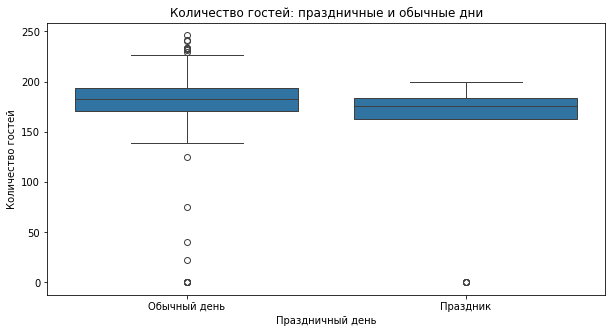

In [59]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="is_holiday",
    y="inside_covers"
)

plt.xlabel("Праздничный день")
plt.ylabel("Количество гостей")
plt.title("Количество гостей: праздничные и обычные дни")

plt.xticks(
    [0, 1],
    ["Обычный день", "Праздник"]
)

plt.show()

In [60]:
# Признак выходного дня
df["is_weekend"] = df["day_of_week"].isin([5, 6])

print(df[[
    "date",
    "day_name",
    "is_weekend",
    "is_holiday",
    "inside_covers"
]].head(10))

        date     day_name  is_weekend  is_holiday  inside_covers
0 2017-01-02  Понедельник       False        True          174.0
1 2017-01-03      Вторник       False       False          181.0
2 2017-01-04        Среда       False       False          174.0
3 2017-01-05      Четверг       False       False          191.0
4 2017-01-06      Пятница       False       False          200.0
5 2017-01-07      Суббота        True       False          209.0
6 2017-01-08  Воскресенье        True       False          188.0
7 2017-01-09  Понедельник       False       False          175.0
8 2017-01-10      Вторник       False       False          179.0
9 2017-01-11        Среда       False       False          187.0


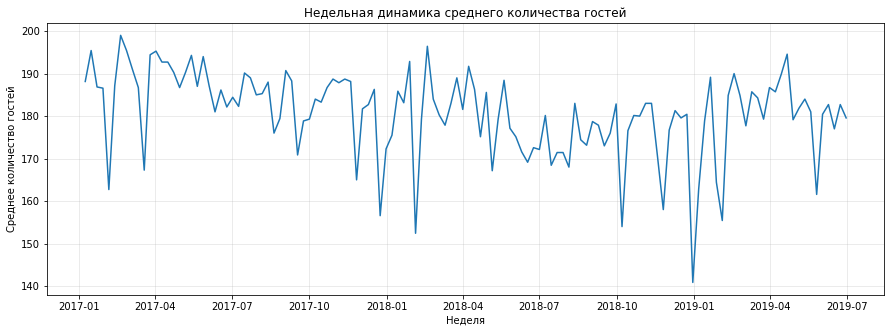

In [61]:
# Сгладим недельное среднее (Это поможет отделить долгосрочные изменения от ежедневного шума)
weekly_mean = (
    df.set_index("date")["inside_covers"]
    .resample("W")
    .mean()
)

plt.figure(figsize=(15, 5))
plt.plot(weekly_mean.index,weekly_mean.values)
plt.xlabel("Неделя")
plt.ylabel("Среднее количество гостей")
plt.title("Недельная динамика среднего количества гостей")
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
holiday_open = df[
    (df["is_holiday"]) &
    (~df["is_closed"]) &
    (df["inside_covers"].notna())
]

holiday_open_comparison = pd.DataFrame({
    "Количество": [
        len(holiday_open),
        len(df[(~df["is_holiday"]) & (df["inside_covers"].notna())])
    ],
    "Среднее": [
        holiday_open["inside_covers"].mean(),
        df.loc[
            (~df["is_holiday"]) & (df["inside_covers"].notna()),
            "inside_covers"
        ].mean()
    ],
    "Медиана": [
        holiday_open["inside_covers"].median(),
        df.loc[
            (~df["is_holiday"]) & (df["inside_covers"].notna()),
            "inside_covers"
        ].median()
    ]
}, index=["Праздник, ресторан открыт", "Обычный день"])

holiday_open_comparison

,Количество,Среднее,Медиана
"Праздник, ресторан открыт",18,179.833333,181.0
Обычный день,885,181.841808,183.0


Когда исключили дни закрытия ресторана, картина стала верной. По этому датасету выраженного снижения гостевого потока именно из-за праздника не наблюдается.

Проверим корреляции. Насколько сильно количество гостей зависит от предыдущего дня и предыдущей недели.

In [63]:
lag_check = df[["inside_covers"]].copy()

lag_check["lag_1"] = lag_check["inside_covers"].shift(1)
lag_check["lag_7"] = lag_check["inside_covers"].shift(7)
lag_check["lag_14"] = lag_check["inside_covers"].shift(14)

lag_check.corr()

,inside_covers,lag_1,lag_7,lag_14
inside_covers,1.000000,0.210125,0.227333,0.188957
lag_1,0.210125,1.000000,0.082392,0.118901
lag_7,0.227333,0.082392,1.000000,0.226954
lag_14,0.188957,0.118901,0.226954,1.000000


lag_1 — гости предыдущего дня

lag_7 — гости 7 дней назад

lag_14 — гости 14 дней назад

Все три корреляции положительные, но не очень сильные. lag_7 немного выше lag_1 и lag_14, что согласуется с обнаруженной нами недельной сезонностью. Но мы всё равно пока оставим все три. 

In [64]:
LAGS = [1, 7, 14]

## Основные выводы

В результате исследовательского анализа установлено следующее:

1. Набор данных содержит ежедневные наблюдения за период с января 2017 года 
   по июнь 2019 года. Календарь является непрерывным, пропущенных календарных 
   дат не обнаружено.

2. В исходных данных были обнаружены пропуски в показателях количества гостей. 
   Они были разделены на закрытые дни и случаи, требующие дополнительной обработки. 
   Закрытые дни были явно обозначены признаком `is_closed`, а не удалены из набора.

3. Количество гостей не демонстрирует выраженного монотонного тренда.

4. Обнаружена выраженная недельная сезонность. Поэтому день недели 
   и признак выходного дня целесообразно использовать в качестве признаков модели.

5. При анализе праздничных дней закрытые праздничные даты были исключены из 
   сравнения. 

8. Корреляционный анализ показал положительную связь количества гостей с 
   значениями целевой переменной в предыдущие дни: корреляция с `lag_1` составила 
   0,210, с `lag_7` — 0,227, с `lag_14` — 0,189. Это подтверждает целесообразность 
   использования лаговых признаков при построении модели.

In [65]:
df.to_csv("../data/processed/restaurant_cleaned.csv", index=False)

print("Файл сохранён.")
print("Размер:", df.shape)
print("Закрытых дней:", df["is_closed"].sum())
print("Праздничных дней:", df["is_holiday"].sum())

Файл сохранён.
Размер: (910, 17)
Закрытых дней: 11
Праздничных дней: 24
